<div id="container" style="position:relative;">
<div style="float:left"><h1> Data Visualizations & Final Project Intro  </h1></div>
<div style="position:relative; float:right">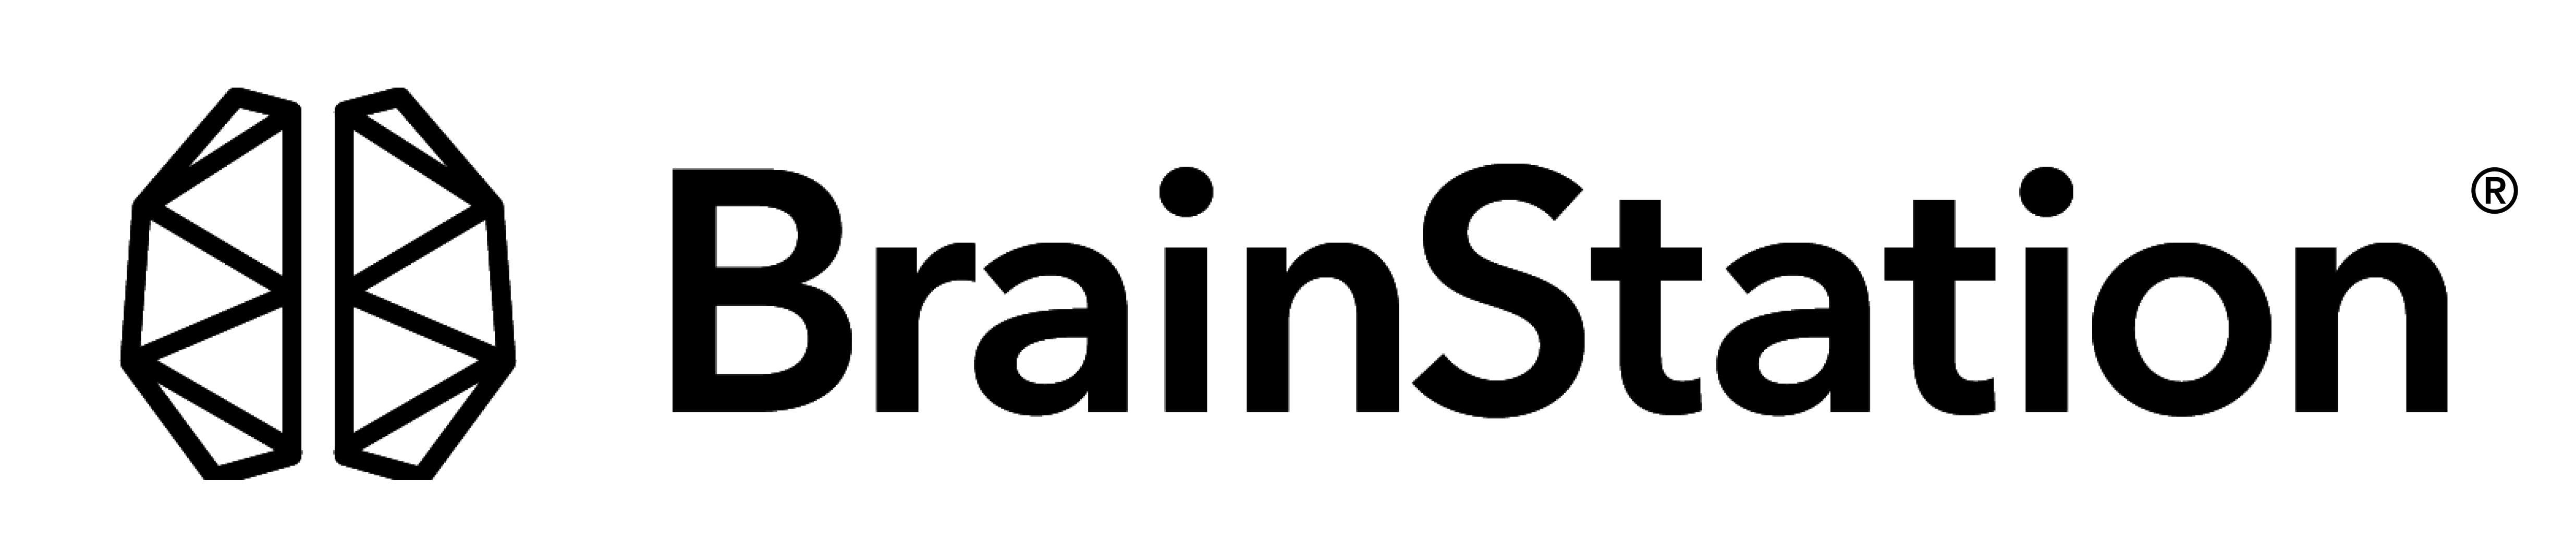
</div>
</div>


# Learning Outcomes

- Learn about various visualization types for exploratory data analysis
- Understand how to use Python libraries for creating informative visualizations.
- Start working on the Python Project Sprint.

Table of Contents
=================

1. [Lesson Introduction](#Lesson-Introduction)
2. [Matplotlib](#Matplotlib)
   - [Step 1: Import Matplotlib](#Step-1:-Import-Matplotlib)
   - [Step 2: Create and Customize Plots](#Step-2:-Create-and-Customize-Plots)
   - [Step 3: Save the Plot](#Step-3:-Save-the-Plot)
3. [Visualization with Building Energy Usage Dataset](#Visualization-with-Building-Energy-Usage-Dataset)
   - [Line Plots](#Line-Plots)
   - [Bar Plots](#Bar-Plots)
   - [Histograms](#Histograms)
   - [Scatter Plots](#Scatter-Plots)
4. [In-Class Code-Along: Visualizations (25 Mins)](#In-Class-Code-Along:-Visualizations-(25-Mins))
5. [Python Project Sprint](#Python-Project-Sprint)
6. [Key Takeaways](#Key-Takeaways)
7. [Next Up](#Next-Up)

# Lesson Introduction  

In the previous lesson, we learned how to work with `NumPy` and `Pandas`, two of the most commonly used libraries in the industry for data cleaning and transformation. We also discussed how Python functions can be used to automate processes and reduce code repetition.

In this lesson, we will explore how to create insightful and effective visualizations that can be used to extract actionable insights and support business decisions. We will discuss the most common types of visualizations used in data analysis and learn how to interpret them. Additionally, we will introduce the **Python Project Sprint** and begin working on it together. The final project will help us review all the concepts we have learned so far and solidify them.

# Matplotlib

Matplotlib is a powerful, versatile library in Python that is widely used for creating static, animated, and interactive visualizations. It was originally developed by John D. Hunter and has since become a foundational tool for data visualization in Python.

The most common module used in matplotlib library is `pyplot` which provides a MATLAB-like interface. It provides access to many different types of charts including line charts, scatter plots, bar charts, histograms, box plots and many more.

Here are the steps to create a chart using matplotlib.


## Step 1: Import Matplotlib

```
import matplotlib.pyplot as plt
```

## Step 2: Create and Customize Plots

Initialize a figure and set the figure size:

```
plt.figure(figsize=(width, height))
```

Specify the type of plot you want to create:

```
plt.plot(x, y)  # For line plots
plt.scatter(x, y)  # For scatter plots
plt.bar(x, height)  # For bar charts
plt.hit(x, bins)  # For histograms
```

Add titles, labels, legend, and grid lines:

```
plt.title("Title")
plt.xlabel("X-axis Label")
plt.ylabel("Y-axis Label")
plt.legend(["Legend Item"])
plt.grid(True) # Optional to add grid lines
```

Display the Plot

```
plt.show()
```

## Step 3: Save the Plot

You can also save the figure for using it in a report.

```
plt.savefig('name.png')
```


## Visualization with Building Energy Usage Dataset

Let's now learn how to use Matplotlib with a building dataset that contains information about Building Automation System (BAS) metrics, such as humidity, temperature, and CO2 levels. This dataset will allow us to visualize key performance indicators (KPIs) and gain valuable insights into the environmental conditions of each segment within the building. Through these visualizations, we can better understand the patterns and trends in the data.

The first step is to import the `matplotlib` library.

In [11]:
# Importing libraries

import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

In [13]:
# Let's read in the dataset
#absolute '/Users/Franny/Documents/Python Programming/Building_metrics.csv'

df = pd.read_csv('~/Documents/Python Programming/Building_metrics.csv')

df.head()

"""

take a look at that first date 

df.dtypes

Unnamed: 0         int64
date              object 
room              object
Temperature      float64
Humidity         float64
Light            float64
CO2              float64
HumidityRatio    float64
Occupancy        float64
Date              object
dtype: object

""""

SyntaxError: unterminated string literal (detected at line 26) (710511202.py, line 26)

# Line Plots

Line plots are primarily used for displaying historical trends and time-series data. They are effective in showing how a metric has changed over time, as well as identifying any anomalies in the data.

In this dataset, we can look into average daily `temperature` and `Humidity` for various rooms in the building. This information help us identify whther if these metrics have been within a comfortable threshold or if they need to be adjusted.

To do so, we can extract the `Date` from the `index` and use that to aggregate the data across various rooms.

In [17]:
# Creating Date column, the reason is so pandas can know for x-axis that it's a date and not a string and correctly uses it. Converting date column to a datime format on pandas

df['date'] = pd.to_datetime(df['date'])
df['Date'] = df['date'].dt.date

In [19]:
df.dtypes

Unnamed: 0                int64
date             datetime64[ns]
room                     object
Temperature             float64
Humidity                float64
Light                   float64
CO2                     float64
HumidityRatio           float64
Occupancy               float64
Date                     object
dtype: object

In [21]:
# Average daily temp and humidity

daily_metrics = df.groupby(['Date', 'room'])[['Temperature', 'Humidity']].mean()
daily_metrics = daily_metrics.reset_index()

daily_metrics.head()

#why is average for one day? because our date is a timestamp level. the way the granualrity is of the data you have multiple readings for the same day, that's why we're calculating average

,Date,room,Temperature,Humidity
0,2024-01-01,Bathroom,22.042233,462.877304
1,2024-01-01,Bedroom,19.711006,328.533669
2,2024-01-01,Kitchen,21.298529,388.056588
3,2024-01-01,Living Room,23.616187,485.337445
4,2024-01-01,Study,21.396712,392.248470


After aggregation the type of the columns can change and we need to ensure that the `Date` column has the right type. So we reset it to `date` type.

In [24]:
# resetting date column to datetime type

daily_metrics['Date'] = pd.to_datetime(daily_metrics['Date'])

In [26]:
daily_metrics.dtypes

Date           datetime64[ns]
room                   object
Temperature           float64
Humidity              float64
dtype: object

We can now visualize the trend for each room. We can visualize them separately or all of them in one single figure. Let's first filter out the data for **Living Room** and visualize it.

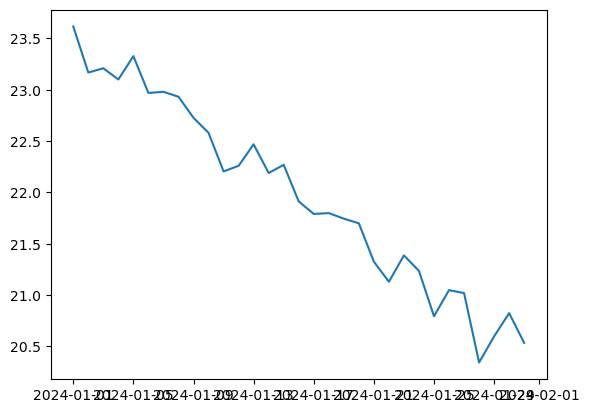

In [29]:
living_room = daily_metrics[daily_metrics['room']=='Living Room']
living_room.head()

# Initiate a figure
plt.figure()

# Create a line plot
plt.plot(living_room['Date'], living_room['Temperature'])

# Display the figure
#plt.show()

As we can see, the x-axis labels are not readable as they are overlapping one another. To fix this issue, we can rote the labels. To do so, we can access the labels using `xticks` method.

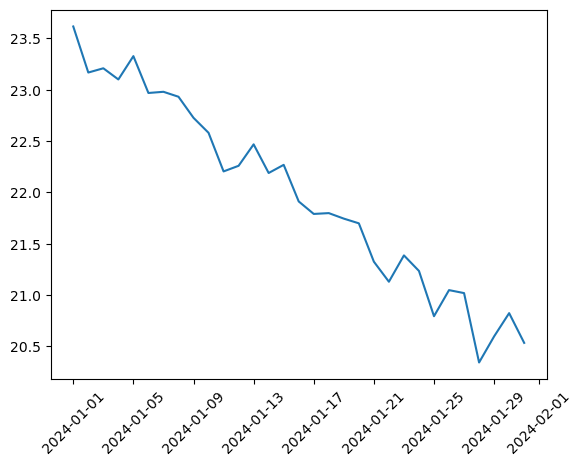

In [32]:
living_room = daily_metrics[daily_metrics['room']=='Living Room']

# Initiate a figure
plt.figure()

# Create a line plot
plt.plot(living_room['Date'], living_room['Temperature'])

# Rotate labels by 45 degrees
plt.xticks(rotation=45)

# Display the figure
plt.show()

To make the chart easier to interpret, we can add title and labels to the axis.

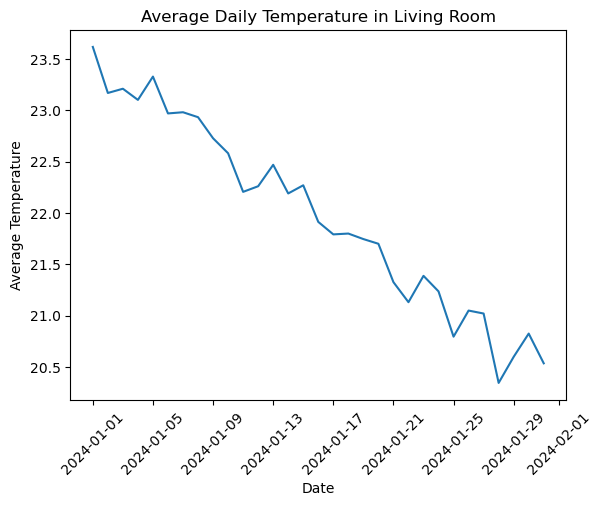

In [35]:
# Initiate a figure
plt.figure()

# Create a line plot
plt.plot(living_room['Date'], living_room['Temperature'])

# Axis labels
plt.xlabel('Date')
plt.ylabel('Average Temperature')

# Adding figure title
plt.title('Average Daily Temperature in Living Room')

# Rotate labels by 45 degrees
plt.xticks(rotation=45)

# Display the figure
plt.show()

The chart clearly shows that the temperature in the living room has been adjusted to lower temperatures towards the end of the month. This can be attributed to probably higher outside temperature. As we can see it dropped by over 3°C and had an average temperature of around 22°C.

To better compare the temperature and humidity in various rooms, we can visualize them all in one single chart. This can be achieved by instantiating a figure and plotting all rooms in the same figure.

In [91]:
# Extracting data for each room

bathroom= daily_metrics[daily_metrics['room']=='Bathroom']
kitchen = daily_metrics[daily_metrics['room']=='Kitchen']
study = daily_metrics[daily_metrics['room']=='Study']
bedroom = daily_metrics[daily_metrics['room']=='Bedroom']

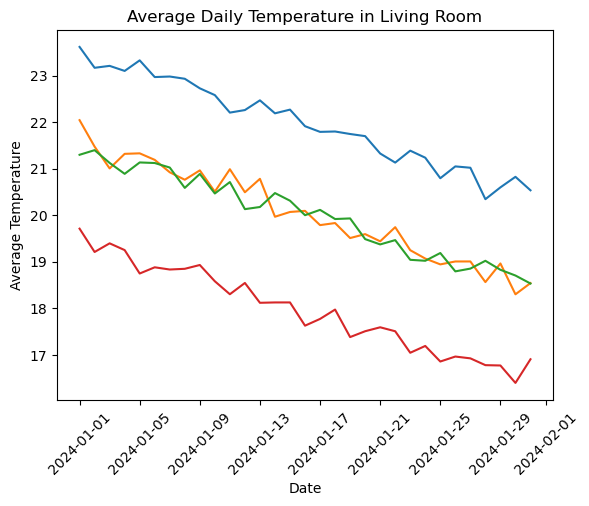

In [93]:
# Initiate a figure
plt.figure()

# Create a line plot
plt.plot(living_room['Date'], living_room['Temperature'])
plt.plot(bathroom['Date'], bathroom['Temperature'])
plt.plot(kitchen['Date'], kitchen['Temperature'])
plt.plot(bedroom['Date'], bedroom['Temperature'])

# Axis labels
plt.xlabel('Date')
plt.ylabel('Average Temperature')

# Adding figure title
plt.title('Average Daily Temperature in Living Room')

# Rotate labels by 45 degrees
plt.xticks(rotation=45)

# Display the figure
plt.show()

We need to add a legend to make sure that we know what each line is showing. We have to first add label to each plot and then call `plt.legend()` function to show it.

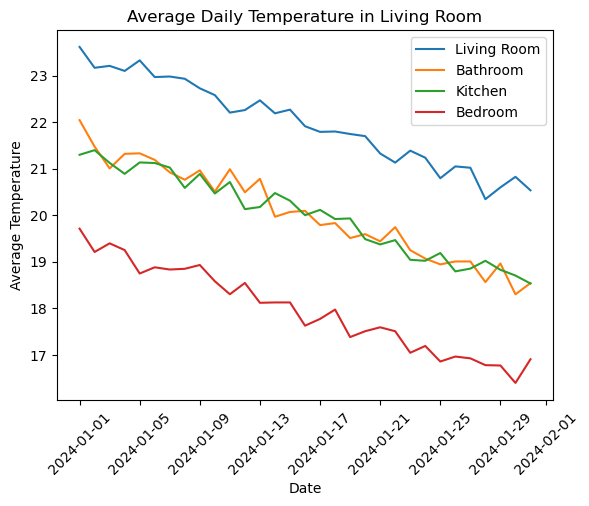

In [43]:
# Initiate a figure
plt.figure()

# Create a line plot
plt.plot(living_room['Date'], living_room['Temperature'], label = 'Living Room')
plt.plot(bathroom['Date'], bathroom['Temperature'], label = 'Bathroom')
plt.plot(kitchen['Date'], kitchen['Temperature'], label = 'Kitchen')
plt.plot(bedroom['Date'], bedroom['Temperature'], label = 'Bedroom')

# Axis labels
plt.xlabel('Date')
plt.ylabel('Average Temperature')

# Adding figure title
plt.title('Average Daily Temperature in Living Room')

# Rotate labels by 45 degrees
plt.xticks(rotation=45)

# Adding legend
plt.legend()

# Display the figure
plt.show()

We can see the same decreasing trend in all four areas. The living room seems to be the warmest area with an average temperature of 22°C, followed by the bathroom and kitchen, which have similar temperatures. The bedroom has the lowest average temperature at 18°C.

# Bar Plots

Bar plots are  primarily used for comparing categorical data across different groups or segments. They are effective in displaying the frequency or magnitude of a particular metric or feature within each group, and can be used to highlight differences or trends between categories. Bar plots are often used when you want to show how a metric varies across multiple categories, such as demographics (e.g., age, gender), geographic regions, or product features.

For our dataset, we can compare the average lighting level and occupancy for different rooms and see if there is any meaningful correlation there.

To do so, we first need to aggregate our data and calculate the average `Lighting Level` and `occupancy` for each room.

In [48]:
# Average daily temp and humidity

room_metrics = df.groupby(['room'])[['Light', 'Occupancy']].mean()
room_metrics = room_metrics.reset_index()

room_metrics.head()


,room,Light,Occupancy
0,Bathroom,357.066044,0.304585
1,Bedroom,309.562587,0.305707
2,Kitchen,354.875990,0.296691
3,Living Room,402.555749,0.697687
4,Study,349.415911,0.098610


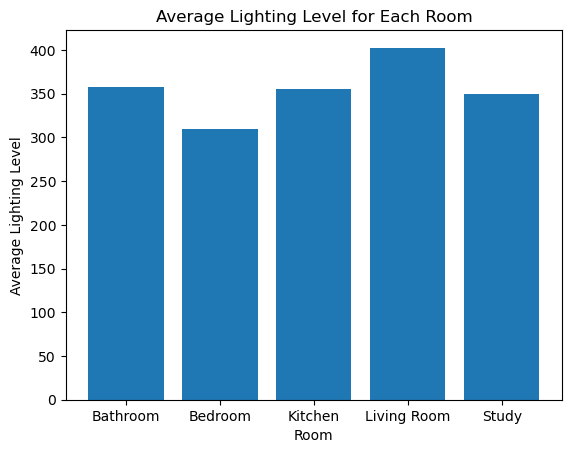

In [50]:
# Initiate a figure
plt.figure()

# Create a bar plot
plt.bar(room_metrics['room'], room_metrics['Light'])

# Axis labels
plt.xlabel('Room')
plt.ylabel('Average Lighting Level')

# Adding figure title
plt.title('Average Lighting Level for Each Room')

# Display the figure
plt.show()

As we expected, **Living Room** has the highest lighting usage and **Bedroom** seems to have the lowest usage. We can now visualize the occupancy for each room.

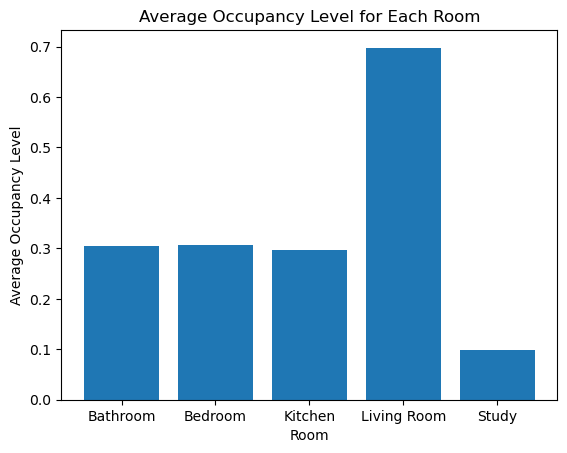

In [53]:
# Initiate a figure
plt.figure()

# Create a bar plot
plt.bar(room_metrics['room'], room_metrics['Occupancy'])

# Axis labels
plt.xlabel('Room')
plt.ylabel('Average Occupancy Level')

# Adding figure title
plt.title('Average Occupancy Level for Each Room')

# Display the figure
plt.show()

This bar plot reveals that the **Living Room** is occupied approximately 70% of the time, consistent with our previous observation of high lighting usage in that area. Conversely, the **Study** room is only occupied about
10% of the time and appears to be utilizing a significant amount of lighting energy. This discrepancy suggests that there may be an issue with the lighting system in this room or that lights are being left on for extended periods when the room is unoccupied.

Adjusting the lighting controls or implementing occupancy-based scheduling could help resolve this problem and lower lighting energy cost.

# Histograms

Histograms display the distribution of data by grouping it into bins or intervals, and showing the frequency or density of each group. They are typically used to visualize continuous data, such as measurements, ages, or times, where the exact values may be important but the overall pattern is more critical. Histograms are useful for identifying trends, patterns, or anomalies in the data, and can help to understand how a particular metric varies across different ranges or bins.

For our dataset we can look into the distribution of **CO2** to see how it has been changing across the entire month. internal **CO2** values has a huge impact on the building comfort level and values above 1000ppm has shown to be dangrous for human health. This can help us to find whthe if the **CO2** crossed this threshold.

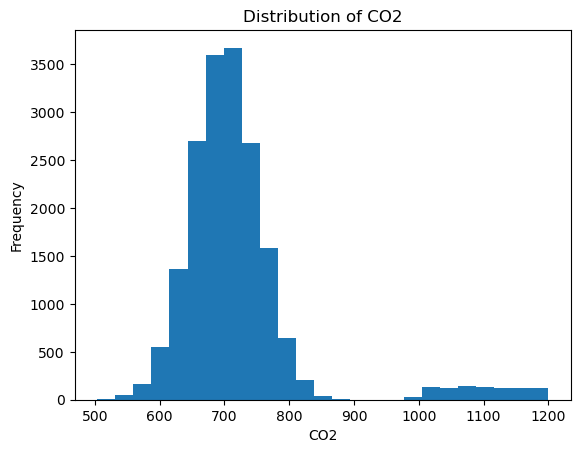

In [58]:
# Initiate a figure
plt.figure()

# Create a line plot
plt.hist(df['CO2'], bins=25)

# Axis labels
plt.xlabel('CO2')
plt.ylabel('Frequency')

# Adding figure title
plt.title('Distribution of CO2')

# Display the figure
plt.show()

As shown here, the CO2 levels appear to be normally distributed across all rooms, with an average concentration of approximately 700 ppm, which falls within the comfortable range for indoor air quality. However, we observe some values exceeding 1000 ppm, indicating that at certain times, the CO2 concentrations exceeded the dangerous threshold. This warrants further investigation and adjustment to ensure a safe and healthy indoor
environment.

# Scatter Plots

A scatter plot is a graphical representation that shows the relationship between two numerical variables by plotting individual data points on a coordinate plane.

Scatter plots are useful for visualizing correlations and patterns in the data, such as linear relationships, non-linear relationships, or no relationship at all. They can help to identify trends, clusters, or outliers in the data, making it easier to understand the underlying relationships between the variables.

For our dataset, we can create a scatter plot to determine whether there is any correlation or relationship between the `temperature` and `humidity` variables.

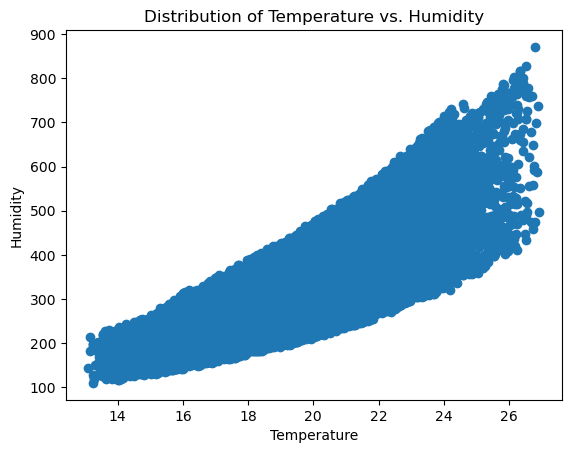

In [63]:
# Initiate a figure
plt.figure()

# Create a line plot
plt.scatter(df['Temperature'], df['Humidity'])

# Axis labels
plt.xlabel('Temperature')
plt.ylabel('Humidity')

# Adding figure title
plt.title('Distribution of Temperature vs. Humidity')

# Display the figure
plt.show()

This scatter plot clearly illustrates the relationship between `Humidity` and `Temperature`. As observed, there is a noticeable increase in humidity levels as the temperature rises, suggesting a strong correlation between these two variables. The relationship appears to be exponential, meaning that the rate of increase in humidity accelerates as the temperature continues to rise. This pattern reflects a common physical phenomenon where warmer air can hold more moisture, leading to higher humidity levels in environments with elevated temperatures.

As discussed above, Matplotlib offers a variety of other charts that can be used to effectively visualize data. Scatter plots are great for showing relationships between two variables and detecting patterns, trends, or clusters. Box plots provide insights into the distribution, spread, and outliers within datasets, making them valuable for statistical analysis.

Moreover, Matplotlib supports pie charts, 3d plots and more, giving you the flexibility to choose the best chart type for your data analysis needs. With these tools, you can create a wide range of visualizations to explore and communicate insights effectively.

## **In-Class Code-Along: Visualizations (25 Mins)**

For this activity, the instructor will code live while you code along with them. As we go, we'll discuss different approaches to each question, ensuring everyone understands the process.

Now that we've explored matplotlib, a versatile library for creating visualizations and drawing insights, let's go through an example together in class.

### Instructions

1. Use the energy usage dataset and overlay the distribution of temperature for **Study Room** on **Living Room** and compare their average temperature. Visualize the average of each distribution using `plt.axvline`.

2. Box plots are another type of charts that are used to show the distribution of a numerical column. They are used to extract statistical information from data. Create a box plot that shows the distribution of `Humidity`? Can you identify the median?

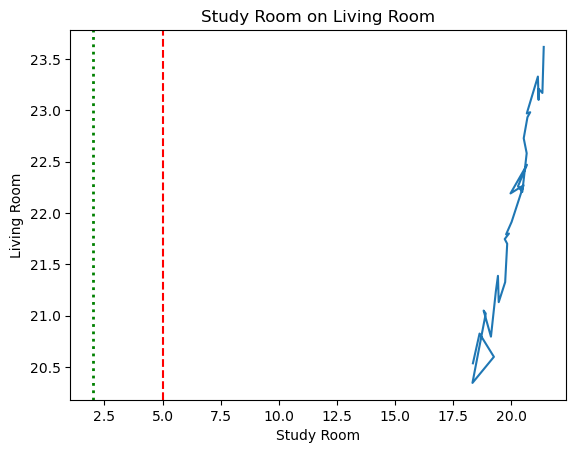

In [89]:
# Write code here

plt.figure()

plt.plot(study['Temperature'], living_room['Temperature'])
# Add a vertical line at x = 5
plt.axvline(x=5, color='r', linestyle='--', label='x = 5')


plt.title("Study Room on Living Room")
plt.xlabel("Study Room")
plt.ylabel("Living Room")


plt.show()

# Python Project Sprint

### Project Description

For the final project, we will undertake a comprehensive task involving the cleaning and analysis of an **E-commerce** dataset. The dataset contains sales records for over 1 year, from December 2022 through December 2023. The goal is to analyze the dataset to determine how sales can be improved and where the focus of the marketing teams should be.

The project will be done in an in-class code-along format where the instructor and students will code and discuss various approaches together in class. The primary objective is to gain hands-on experience using Python for data transformation and visualization. Throughout the project, we will work with various Python structures, data types, and functions to achieve the project goals.

The project will include several steps:

1. **Data Cleaning and Preprocessing**:
   - We will clean the dataset by addressing missing values, eliminating duplicates, correcting data types, and resolving any inconsistencies.
   - To streamline this process, we will develop a Python function at the end that takes the raw dataset and specific parameters as inputs (e.g., how to handle missing values, whether to drop duplicates) and outputs a cleaned dataset. This function will allow us to automate our cleaning process for this dataset.

2. **Visualization and Insights Extraction**:
   - Using Matplotlib, we will create visualizations that reveal key trends, patterns, and insights within the dataset.

3. **Business Insights**:
   - We will discuss the results together as we create our visualizations to extract insights that help us answer the project goal.

Through this project, you will apply your Python skills to real-world data, emphasizing the critical role of data cleaning in the analytical process and the benefits of automation in various workflows.

# Key Takeaways

- Identifying hidden trends in the data is a crucial aspect of any project, and should be accompanied by actionable insights that inform business decisions.
- A variety of visualizations should be employed to showcase the relationship between numerical or categorical metrics, facilitating easier interpretation of trends and patterns.

# Next Up
#### Lesson 4, Module 2 & Lesson 5

We have now covered the key concepts of Python programming and its application in basic data analysis. In our next session, we will continue working together on the Python Project Sprint, then explore next steps and additional concepts related to Python.

<div id="container" style="position:relative;">
    <div style="position:relative; float:right">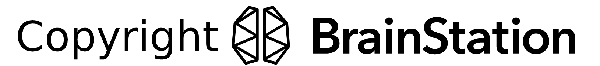
    </div>
</div>